<a href="https://colab.research.google.com/github/MuhammadAqsandy/scikit-learn-cookbook/blob/main/chapter_10_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Clustering Techniques
## 📌 Summary
Clustering adalah **unsupervised learning** yang mengelompokkan data tanpa label. Teknik utama: **K-Means**, **DBSCAN**, **Hierarchical Clustering**, dan **Gaussian Mixture Models**.

## 🧠 Theoretical Deep-Dive

### 10.1 K-Means
Minimize inertia (within-cluster sum of squares):
J = Σᵢ Σ_{x∈Cᵢ} ||x - μᵢ||²

**Algorithm:**
1. Initialize k centroids (random or K-Means++)
2. Assign points ke centroid terdekat
3. Update centroid = mean of cluster
4. Repeat sampai konvergen

**Kelemahan**: harus tentukan k, sensitif outlier, asumsi spherical clusters.

### 10.2 DBSCAN
Density-based: cluster = region dengan density tinggi.
- **ε (eps)**: radius neighborhood
- **min_samples**: min points untuk core point
- **Core point**: ≥ min_samples dalam ε-neighborhood
- **Keunggulan**: deteksi anomaly (noise points = -1), clusters bentuk apapun, tidak perlu tentukan k

### 10.3 Hierarchical Clustering
- **Agglomerative** (bottom-up): mulai dengan setiap point sebagai cluster, lalu merge terdekat
- **Divisive** (top-down): mulai dengan satu cluster, lalu split
- Visualisasi via **dendrogram**

### 10.4 Cluster Evaluation
- **Silhouette score**: [-1, 1] → seberapa baik point cocok di cluster-nya vs cluster tetangga
- **Davies-Bouldin index**: lebih rendah = lebih baik
- **Elbow method**: plot inertia vs k, cari 'elbow'

## 💻 Code Reproduction

Inertia: 11.32
Silhouette score: 0.8386
Cluster centers shape: (4, 2)


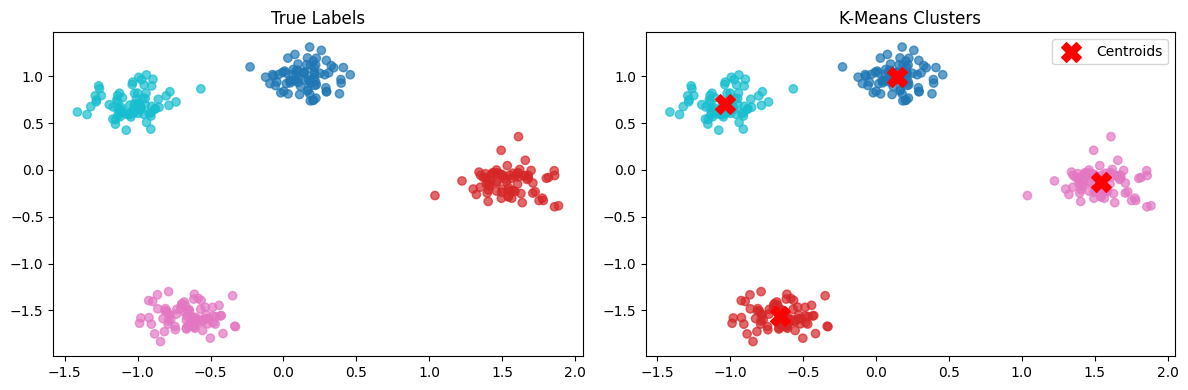

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X_s = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)
labels = kmeans.fit_predict(X_s)

print("Inertia:", round(kmeans.inertia_, 2))
print("Silhouette score:", round(silhouette_score(X_s, labels), 4))
print("Cluster centers shape:", kmeans.cluster_centers_.shape)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_s[:, 0], X_s[:, 1], c=y_true, cmap="tab10", alpha=0.7)
plt.title("True Labels")
plt.subplot(1, 2, 2)
plt.scatter(X_s[:, 0], X_s[:, 1], c=labels, cmap="tab10", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c="red", marker="X", label="Centroids")
plt.title("K-Means Clusters"); plt.legend()
plt.tight_layout(); plt.show()

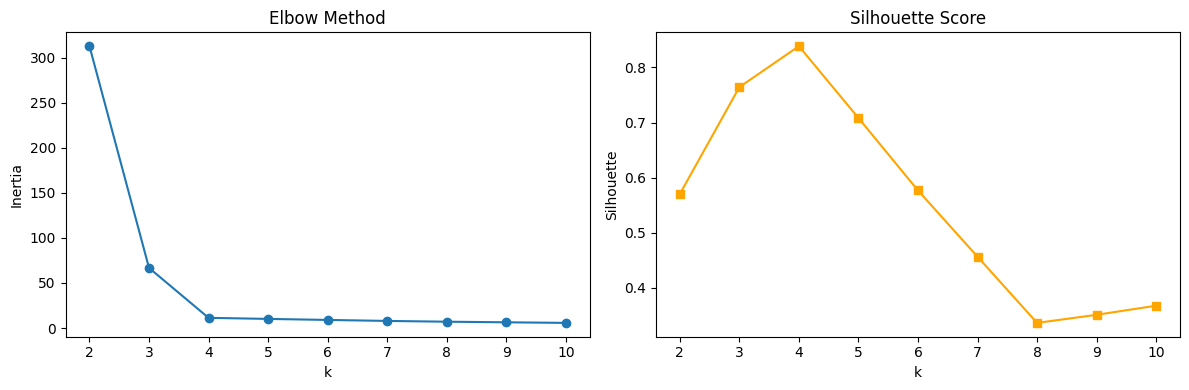

Best k (silhouette): 4


In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X_s = StandardScaler().fit_transform(X)

k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_s)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_s, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertias, marker="o"); ax1.set_xlabel("k"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow Method")
ax2.plot(k_range, silhouettes, marker="s", color="orange"); ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette Score")
plt.tight_layout(); plt.show()
print("Best k (silhouette):", k_range[silhouettes.index(max(silhouettes))])

Clusters found: 2
Noise points: 2


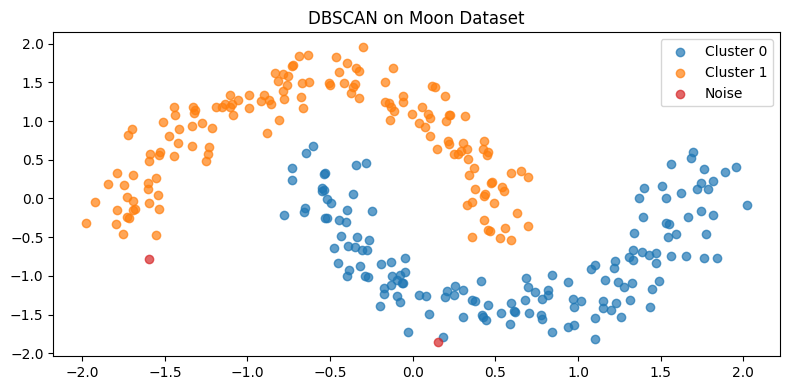

In [4]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
X_s = StandardScaler().fit_transform(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_s)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")

plt.figure(figsize=(8, 4))
colors = ["tab:blue", "tab:orange", "tab:red"]  # cluster 0, 1, noise
for label, color, name in zip([0, 1, -1], colors, ["Cluster 0", "Cluster 1", "Noise"]):
    mask = labels == label
    plt.scatter(X_s[mask, 0], X_s[mask, 1], c=color, label=name, alpha=0.7)
plt.title("DBSCAN on Moon Dataset")
plt.legend(); plt.tight_layout(); plt.show()

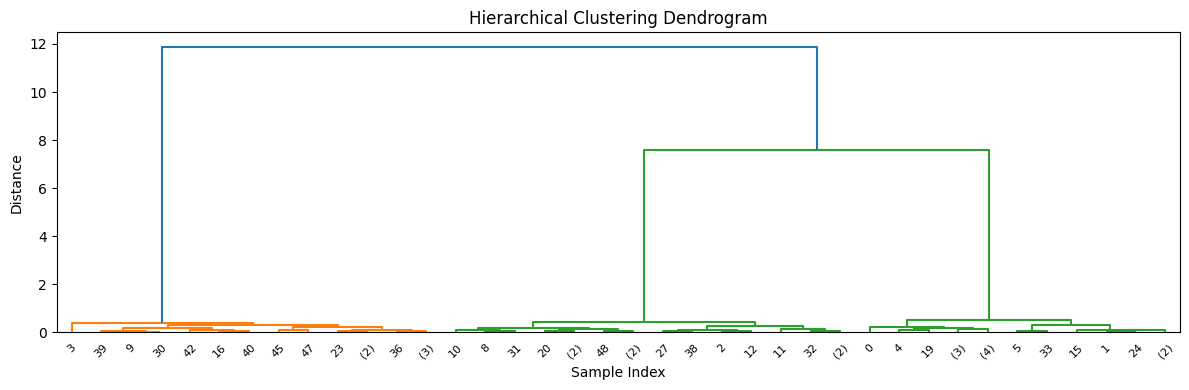

linkage=ward      : silhouette=0.9283
linkage=complete  : silhouette=0.9283
linkage=average   : silhouette=0.9283
linkage=single    : silhouette=0.9283


In [5]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.5, random_state=42)
X_s = StandardScaler().fit_transform(X)

# Dendrogram
Z = linkage(X_s, method="ward")
plt.figure(figsize=(12, 4))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

# Agglomerative
for linkage_method in ["ward", "complete", "average", "single"]:
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage_method)
    labels = agg.fit_predict(X_s)
    from sklearn.metrics import silhouette_score
    score = silhouette_score(X_s, labels)
    print(f"linkage={linkage_method:10}: silhouette={score:.4f}")

## ✅ Chapter Summary
- **K-Means**: cepat, scalable, tapi perlu k dan asumsi spherical clusters
- **DBSCAN**: tidak perlu k, deteksi noise/outlier, works dengan arbitrary shapes
- **Hierarchical**: tidak perlu k di awal, visualisasi dendrogram membantu
- **Elbow method + Silhouette** untuk pilih k optimal
- Selalu **standardize** data sebelum clustering
- Silhouette score > 0.5 = clustering baik; > 0.7 = sangat baik